In [1]:
import numpy as np
import matplotlib.pyplot as plt
from planar_utils import plot_decision_boundary, sigmoid, load_planar_dataset

np.random.seed(1)

In [2]:
X, Y = load_planar_dataset()

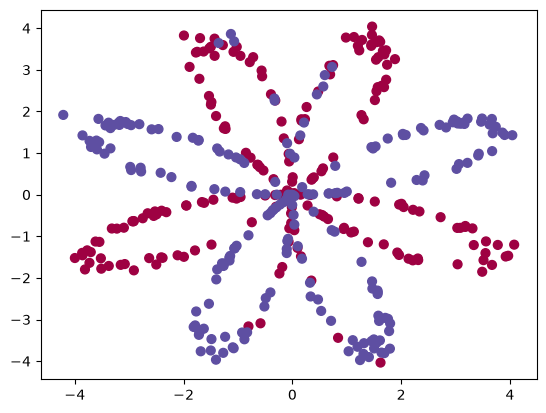

In [3]:
plt.scatter(X[0, :], X[1, :], c=Y, s=40, cmap=plt.cm.Spectral)

In [5]:
# (≈ 3 lines of code)
# shape_X = ...
# shape_Y = ...
# training set size
# m = ...
# YOUR CODE STARTS HERE
shape_X = X.shape
shape_Y = Y.shape
m = X.shape[1]
# YOUR CODE ENDS HERE

print ('The shape of X is: ' + str(shape_X))
print ('The shape of Y is: ' + str(shape_Y))
print ('I have m = %d training examples!' % (m))

The shape of X is: (2, 400)
The shape of Y is: (1, 400)
I have m = 400 training examples!


In [6]:
# GRADED FUNCTION: layer_sizes

def layer_sizes(X, Y):
    """
    Arguments:
    X -- input dataset of shape (input size, number of examples)
    Y -- labels of shape (output size, number of examples)
    
    Returns:
    n_x -- the size of the input layer
    n_h -- the size of the hidden layer
    n_y -- the size of the output layer
    """
    #(≈ 3 lines of code)
    # n_x = ... 
    # n_h = ...
    # n_y = ... 
    # YOUR CODE STARTS HERE
    n_x = X.shape[0]
    n_h = 4
    n_y = Y.shape[0]
    
    # YOUR CODE ENDS HERE
    return (n_x, n_h, n_y)

In [8]:
t_X, t_Y = X, Y
n_x, n_h, n_y = layer_sizes(t_X, t_Y)
print("The size of the input layer is: n_x = " + str(n_x))
print("The size of the hidden layer is: n_h = " + str(n_h))
print("The size of the output layer is: n_y = " + str(n_y))

The size of the input layer is: n_x = 2
The size of the hidden layer is: n_h = 4
The size of the output layer is: n_y = 1


In [11]:
# GRADED FUNCTION: initialize_parameters

def initialize_parameters(n_x, n_h, n_y):
    """
    Argument:
    n_x -- size of the input layer
    n_h -- size of the hidden layer
    n_y -- size of the output layer
    
    Returns:
    params -- python dictionary containing your parameters:
                    W1 -- weight matrix of shape (n_h, n_x)
                    b1 -- bias vector of shape (n_h, 1)
                    W2 -- weight matrix of shape (n_y, n_h)
                    b2 -- bias vector of shape (n_y, 1)
    """    
    #(≈ 4 lines of code)
    # W1 = ...
    # b1 = ...
    # W2 = ...
    # b2 = ...
    # YOUR CODE STARTS HERE
    W1 = np.random.randn(n_h, n_x) * 0.01
    b1 = np.zeros((n_h, 1))
    W2 = np.random.randn(n_y, n_h) * 0.01
    b2 = np.zeros((n_y, 1))
    
    # YOUR CODE ENDS HERE

    parameters = {"W1": W1,
                  "b1": b1,
                  "W2": W2,
                  "b2": b2}
    
    return parameters

In [12]:
def initialize_parameters_test(target):
    n_x, n_h, n_y = 3, 5, 2
    parameters = target(n_x, n_h, n_y)

    assert type(parameters['W1']) == np.ndarray, "W1 must be a numpy array"
    assert type(parameters['b1']) == np.ndarray, "b1 must be a numpy array"
    assert type(parameters['W2']) == np.ndarray, "W2 must be a numpy array"
    assert type(parameters['b2']) == np.ndarray, "b2 must be a numpy array"

    assert parameters['W1'].shape == (n_h, n_x), f"W1 shape mismatch, expected ({n_h},{n_x})"
    assert parameters['b1'].shape == (n_h, 1), f"b1 shape mismatch, expected ({n_h},1)"
    assert parameters['W2'].shape == (n_y, n_h), f"W2 shape mismatch, expected ({n_y},{n_h})"
    assert parameters['b2'].shape == (n_y, 1), f"b2 shape mismatch, expected ({n_y},1)"

    assert np.all(parameters['b1'] == 0), "b1 must be initialized with zeros"
    assert np.all(parameters['b2'] == 0), "b2 must be initialized with zeros"

    print("\033[92mAll tests passed!")

initialize_parameters_test(initialize_parameters)

All tests passed!


In [13]:
# GRADED FUNCTION:forward_propagation

def forward_propagation(X, parameters):
    """
    Argument:
    X -- input data of size (n_x, m)
    parameters -- python dictionary containing your parameters (output of initialization function)
    
    Returns:
    A2 -- The sigmoid output of the second activation
    cache -- a dictionary containing "Z1", "A1", "Z2" and "A2"
    """
    # Retrieve each parameter from the dictionary "parameters"
    #(≈ 4 lines of code)
    # W1 = ...
    # b1 = ...
    # W2 = ...
    # b2 = ...
    # YOUR CODE STARTS HERE
    W1 = parameters["W1"]
    b1 = parameters["b1"]
    W2 = parameters["W2"]
    b2 = parameters["b2"]
    
    # YOUR CODE ENDS HERE
    
    # Implement Forward Propagation to calculate A2 (probabilities)
    # (≈ 4 lines of code)
    # Z1 = ...
    # A1 = ...
    # Z2 = ...
    # A2 = ...
    # YOUR CODE STARTS HERE
    Z1 = np.dot(W1, X) + b1
    A1 = np.tanh(Z1)
    Z2 = np.dot(W2, A1) + b2
    A2 = sigmoid(Z2)
    
    # YOUR CODE ENDS HERE
    
    assert(A2.shape == (1, X.shape[1]))
    
    cache = {"Z1": Z1,
             "A1": A1,
             "Z2": Z2,
             "A2": A2}
    
    return A2, cache

In [15]:
def forward_propagation_test(target):
    np.random.seed(1)
    X = np.random.randn(2, 3)

    parameters = {
        "W1": np.array([[-0.00416758, -0.00056267], [-0.02136196, 0.01640271], [-0.01793436, -0.00841747], [0.00502881, -0.01245288]]),
        "b1": np.array([[0.], [0.], [0.], [0.]]),
        "W2": np.array([[-0.01057952, -0.00909008, 0.00551454, 0.02292208]]),
        "b2": np.array([[0.]])
    }

    A2, cache = target(X, parameters)
    print("Z1 =", cache["Z1"])
    print("A1 =", cache["A1"])
    print("Z2 =", cache["Z2"])
    print("A2 =", A2)

forward_propagation_test(forward_propagation)

Z1 = [[-0.00616586  0.0020626   0.0034962 ]
 [-0.05229879  0.02726335 -0.02646869]
 [-0.02009991  0.00368692  0.02884556]
 [ 0.02153007 -0.01385322  0.02600471]]
A1 = [[-0.00616578  0.0020626   0.00349619]
 [-0.05225116  0.02725659 -0.02646251]
 [-0.02009721  0.0036869   0.02883756]
 [ 0.02152675 -0.01385234  0.02599885]]
Z2 = [[ 0.00092281 -0.00056678  0.00095853]]
A2 = [[0.5002307  0.49985831 0.50023963]]


In [16]:
# GRADED FUNCTION: compute_cost

def compute_cost(A2, Y):
    """
    Computes the cross-entropy cost given in equation (13)
    
    Arguments:
    A2 -- The sigmoid output of the second activation, of shape (1, number of examples)
    Y -- "true" labels vector of shape (1, number of examples)

    Returns:
    cost -- cross-entropy cost given equation (13)
    
    """
    
    m = Y.shape[1] # number of examples

    # Compute the cross-entropy cost
    # (≈ 2 lines of code)
    # logprobs = ...
    # cost = ...
    # YOUR CODE STARTS HERE
    logprobs = np.multiply(np.log(A2), Y) + np.multiply(np.log(1 - A2), 1 - Y)
    cost = -np.sum(logprobs) / m
    
    # YOUR CODE ENDS HERE
    
    cost = float(np.squeeze(cost))  # makes sure cost is the dimension we expect. 
                                    # E.g., turns [[17]] into 17 
    
    return cost

In [17]:
# GRADED FUNCTION: backward_propagation

def backward_propagation(parameters, cache, X, Y):
    """
    Implement the backward propagation using the instructions above.
    
    Arguments:
    parameters -- python dictionary containing our parameters 
    cache -- a dictionary containing "Z1", "A1", "Z2" and "A2".
    X -- input data of shape (2, number of examples)
    Y -- "true" labels vector of shape (1, number of examples)
    
    Returns:
    grads -- python dictionary containing your gradients with respect to different parameters
    """
    m = X.shape[1]
    
    # First, retrieve W1 and W2 from the dictionary "parameters".
    #(≈ 2 lines of code)
    # W1 = ...
    # W2 = ...
    # YOUR CODE STARTS HERE
    W1 = parameters["W1"]
    W2 = parameters["W2"]
    
    # YOUR CODE ENDS HERE
        
    # Retrieve also A1 and A2 from dictionary "cache".
    #(≈ 2 lines of code)
    # A1 = ...
    # A2 = ...
    # YOUR CODE STARTS HERE
    A1 = cache["A1"]
    A2 = cache["A2"]
    
    # YOUR CODE ENDS HERE
    
    # Backward propagation: calculate dW1, db1, dW2, db2. 
    #(≈ 6 lines of code, corresponding to 6 equations on slide above)
    # dZ2 = ...
    # dW2 = ...
    # db2 = ...
    # dZ1 = ...
    # dW1 = ...
    # db1 = ...
    # YOUR CODE STARTS HERE
    dZ2 = A2 - Y
    dW2 = 1/m * np.dot(dZ2, A1.T)
    db2 = 1/m * np.sum(dZ2, axis=1, keepdims=True)
    dZ1 = np.dot(W2.T, dZ2) * (1 - np.power(A1, 2))
    dW1 = 1/m * np.dot(dZ1, X.T)
    db1 = 1/m * np.sum(dZ1, axis=1, keepdims=True)
    
    # YOUR CODE ENDS HERE
    
    grads = {"dW1": dW1,
             "db1": db1,
             "dW2": dW2,
             "db2": db2}
    
    return grads

In [18]:
def backward_propagation_test(target):
    np.random.seed(1)
    X = np.random.randn(2, 3)
    Y = (np.random.randn(1, 3) > 0)

    parameters = {
        "W1": np.array([[-0.00416758, -0.00056267], [-0.02136196, 0.01640271], [-0.01793436, -0.00841747], [0.00502881, -0.01245288]]),
        "W2": np.array([[-0.01057952, -0.00909008, 0.00551454, 0.02292208]]),
        "b1": np.array([[0.], [0.], [0.], [0.]]),
        "b2": np.array([[0.]])
    }

    cache = {
        "A1": np.array([[-0.00616578, 0.0020626, 0.00349619],
                         [-0.05225116, 0.02725659, -0.02646251],
                         [-0.02009721, 0.0036869, 0.02883756],
                         [ 0.02152675, -0.01385234, 0.02599885]]),
        "A2": np.array([[0.5002307, 0.49985831, 0.50023963]]),
        "Z1": np.array([[-0.00616586, 0.0020626, 0.0034962],
                         [-0.05229879, 0.02726335, -0.02646869],
                         [-0.02009991, 0.00368692, 0.02884556],
                         [ 0.02153007, -0.01385322, 0.02600471]]),
        "Z2": np.array([[0.00092281, -0.00056678, 0.00095853]])
    }

    grads = target(parameters, cache, X, Y)

    print("dW1 =\n" + str(grads["dW1"]))
    print("db1 =\n" + str(grads["db1"]))
    print("dW2 =\n" + str(grads["dW2"]))
    print("db2 =\n" + str(grads["db2"]))

backward_propagation_test(backward_propagation)

dW1 =
[[ 0.00301023 -0.00747267]
 [ 0.00257968 -0.00641288]
 [-0.00156892  0.003893  ]
 [-0.00652037  0.01618243]]
db1 =
[[ 0.00176201]
 [ 0.00150995]
 [-0.00091736]
 [-0.00381422]]
dW2 =
[[ 0.00078841  0.01765429 -0.00084166 -0.01022527]]
db2 =
[[-0.16655712]]


In [21]:
# GRADED FUNCTION: update_parameters

import copy

def update_parameters(parameters, grads, learning_rate = 1.2):
    """
    Updates parameters using the gradient descent update rule given above
    
    Arguments:
    parameters -- python dictionary containing your parameters 
    grads -- python dictionary containing your gradients 
    
    Returns:
    parameters -- python dictionary containing your updated parameters 
    """
    # Retrieve a copy of each parameter from the dictionary "parameters". Use copy.deepcopy(...) for W1 and W2
    #(≈ 4 lines of code)
    # W1 = ...
    # b1 = ...
    # W2 = ...
    # b2 = ...
    # YOUR CODE STARTS HERE
    W1 = copy.deepcopy(parameters["W1"])
    b1 = parameters["b1"]
    W2 = copy.deepcopy(parameters["W2"])
    b2 = parameters["b2"]
    
    # YOUR CODE ENDS HERE
    
    # Retrieve each gradient from the dictionary "grads"
    #(≈ 4 lines of code)
    # dW1 = ...
    # db1 = ...
    # dW2 = ...
    # db2 = ...
    # YOUR CODE STARTS HERE
    dW1 = grads["dW1"]
    db1 = grads["db1"]
    dW2 = grads["dW2"]
    db2 = grads["db2"]
    
    # YOUR CODE ENDS HERE
    
    # Update rule for each parameter
    #(≈ 4 lines of code)
    # W1 = ...
    # b1 = ...
    # W2 = ...
    # b2 = ...
    # YOUR CODE STARTS HERE
    W1 = W1 - learning_rate * dW1
    b1 = b1 - learning_rate * db1
    W2 = W2 - learning_rate * dW2
    b2 = b2 - learning_rate * db2
    
    # YOUR CODE ENDS HERE
    
    parameters = {"W1": W1,
                  "b1": b1,
                  "W2": W2,
                  "b2": b2}
    
    return parameters

In [22]:
def update_parameters_test(target):
    parameters = {
        "W1": np.array([[-0.00615039, 0.0169021], [-0.02311792, 0.03137121], [-0.0169217, -0.01752545], [0.00935436, -0.05018221]]),
        "b1": np.array([[-8.97523455e-07], [8.15562092e-06], [6.04810633e-07], [-2.54560700e-06]]),
        "W2": np.array([[-0.01057952, -0.00909008, 0.00551454, 0.02292208]]),
        "b2": np.array([[0.00010457]])
    }

    grads = {
        "dW1": np.array([[0.00023322, -0.00205423], [0.00082222, -0.00700776], [-0.00031831, 0.0028636], [-0.00092857, 0.00809933]]),
        "db1": np.array([[-1.75740039e-05], [3.70231337e-03], [-1.25683095e-03], [2.55715317e-03]]),
        "dW2": np.array([[0.00181312, 0.00849792, -0.00204671, -0.01023233]]),
        "db2": np.array([[-1.75409657e-04]])
    }

    parameters = target(parameters, grads, learning_rate=0.1)

    print("W1 =\n" + str(parameters["W1"]))
    print("b1 =\n" + str(parameters["b1"]))
    print("W2 =\n" + str(parameters["W2"]))
    print("b2 =\n" + str(parameters["b2"]))

update_parameters_test(update_parameters)

W1 =
[[-0.00617371  0.01710752]
 [-0.02320014  0.03207199]
 [-0.01688987 -0.01781181]
 [ 0.00944722 -0.05099214]]
b1 =
[[ 8.59876935e-07]
 [-3.62075716e-04]
 [ 1.26287906e-04]
 [-2.58260924e-04]]
W2 =
[[-0.01076083 -0.00993987  0.00571921  0.02394531]]
b2 =
[[0.00012211]]


In [23]:
# GRADED FUNCTION: nn_model

def nn_model(X, Y, n_h, num_iterations = 10000, print_cost=False):
    """
    Arguments:
    X -- dataset of shape (2, number of examples)
    Y -- labels of shape (1, number of examples)
    n_h -- size of the hidden layer
    num_iterations -- Number of iterations in gradient descent loop
    print_cost -- if True, print the cost every 1000 iterations
    
    Returns:
    parameters -- parameters learnt by the model. They can then be used to predict.
    """
    
    np.random.seed(3)
    n_x = layer_sizes(X, Y)[0]
    n_y = layer_sizes(X, Y)[2]
    
    # Initialize parameters
    #(≈ 1 line of code)
    # parameters = ...
    # YOUR CODE STARTS HERE
    parameters = initialize_parameters(n_x, n_h, n_y)
    
    # YOUR CODE ENDS HERE
    
    # Loop (gradient descent)

    for i in range(0, num_iterations):
         
        #(≈ 4 lines of code)
        # Forward propagation. Inputs: "X, parameters". Outputs: "A2, cache".
        # A2, cache = ...
        
        # Cost function. Inputs: "A2, Y". Outputs: "cost".
        # cost = ...
 
        # Backpropagation. Inputs: "parameters, cache, X, Y". Outputs: "grads".
        # grads = ...
 
        # Gradient descent parameter update. Inputs: "parameters, grads". Outputs: "parameters".
        # parameters = ...
        
        # YOUR CODE STARTS HERE
        A2, cache = forward_propagation(X, parameters)
        cost = compute_cost(A2, Y)
        grads = backward_propagation(parameters, cache, X, Y)
        parameters = update_parameters(parameters, grads)
        # YOUR CODE ENDS HERE
        
        # Print the cost every 1000 iterations
        if print_cost and i % 1000 == 0:
            print ("Cost after iteration %i: %f" %(i, cost))

    return parameters

In [24]:
def nn_model_test(target):
    np.random.seed(1)
    X = np.random.randn(2, 3)
    Y = (np.random.randn(1, 3) > 0)

    parameters = target(X, Y, 4, num_iterations=10000, print_cost=False)

    print("W1 =\n" + str(parameters["W1"]))
    print("b1 =\n" + str(parameters["b1"]))
    print("W2 =\n" + str(parameters["W2"]))
    print("b2 =\n" + str(parameters["b2"]))

nn_model_test(nn_model)

W1 =
[[ 0.56305445 -1.03925886]
 [ 0.7345426  -1.36286875]
 [-0.72533346  1.33753027]
 [ 0.74757629 -1.38274074]]
b1 =
[[-0.22240654]
 [-0.34662093]
 [ 0.33663708]
 [-0.35296113]]
W2 =
[[ 1.82196893  3.09657075 -2.98193564  3.19946508]]
b2 =
[[0.21344644]]


In [25]:
# GRADED FUNCTION: predict

def predict(parameters, X):
    """
    Using the learned parameters, predicts a class for each example in X
    
    Arguments:
    parameters -- python dictionary containing your parameters 
    X -- input data of size (n_x, m)
    
    Returns
    predictions -- vector of predictions of our model (red: 0 / blue: 1)
    """
    
    # Computes probabilities using forward propagation, and classifies to 0/1 using 0.5 as the threshold.
    #(≈ 2 lines of code)
    # A2, cache = ...
    # predictions = ...
    # YOUR CODE STARTS HERE
    A2, cache = forward_propagation(X, parameters)
    predictions = A2 > 0.5
    
    # YOUR CODE ENDS HERE
    
    return predictions

In [26]:
def predict_test(target):
    np.random.seed(1)
    X = np.random.randn(2, 3)
    parameters = {
        "W1": np.array([[-0.00615039, 0.0169021], [-0.02311792, 0.03137121], [-0.0169217, -0.01752545], [0.00935436, -0.05018221]]),
        "b1": np.array([[-8.97523455e-07], [8.15562092e-06], [6.04810633e-07], [-2.54560700e-06]]),
        "W2": np.array([[-0.01057952, -0.00909008, 0.00551454, 0.02292208]]),
        "b2": np.array([[0.00010457]])
    }

    predictions = target(parameters, X)
    print("predictions = " + str(predictions))

predict_test(predict)

predictions = [[ True False  True]]


In [27]:
parameters = nn_model(X, Y, n_h=4, num_iterations=10000, print_cost=True)

Cost after iteration 0: 0.693162
Cost after iteration 1000: 0.258625
Cost after iteration 2000: 0.239334
Cost after iteration 3000: 0.230802
Cost after iteration 4000: 0.225528
Cost after iteration 5000: 0.221845
Cost after iteration 6000: 0.219094
Cost after iteration 7000: 0.220617
Cost after iteration 8000: 0.219412
Cost after iteration 9000: 0.218526


Text(0.5, 1.0, 'Decision Boundary for hidden layer size 4')

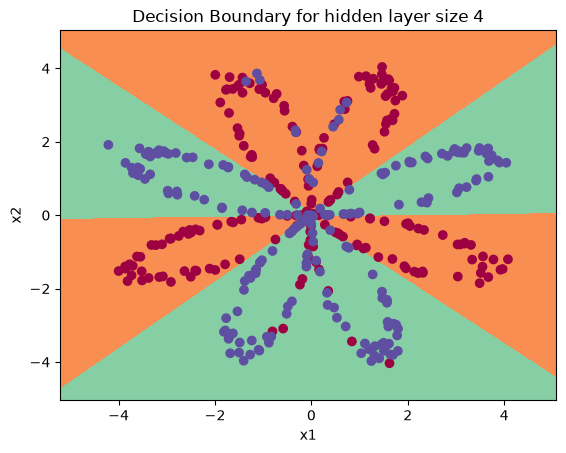

In [28]:
plot_decision_boundary(lambda x: predict(parameters, x.T), X, Y)
plt.title("Decision Boundary for hidden layer size " + str(4))

In [31]:
predictions = predict(parameters, X)
accuracy = np.mean(predictions == Y) * 100
print('Accuracy: %.2f%%' % accuracy)

Accuracy: 90.50%


Text(0.5, 1.0, 'Decision Boundary for hidden layer size 4')

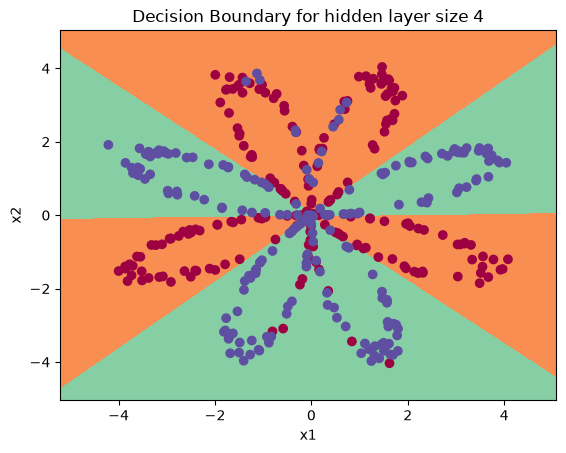

In [32]:
plot_decision_boundary(lambda x: predict(parameters, x.T), X, Y)
plt.title("Decision Boundary for hidden layer size " + str(4))

Accuracy for 1 hidden units: 67.50 %
Accuracy for 2 hidden units: 67.25 %
Accuracy for 3 hidden units: 90.75 %
Accuracy for 4 hidden units: 90.50 %
Accuracy for 5 hidden units: 91.25 %
Accuracy for 20 hidden units: 91.00 %
Accuracy for 50 hidden units: 90.50 %


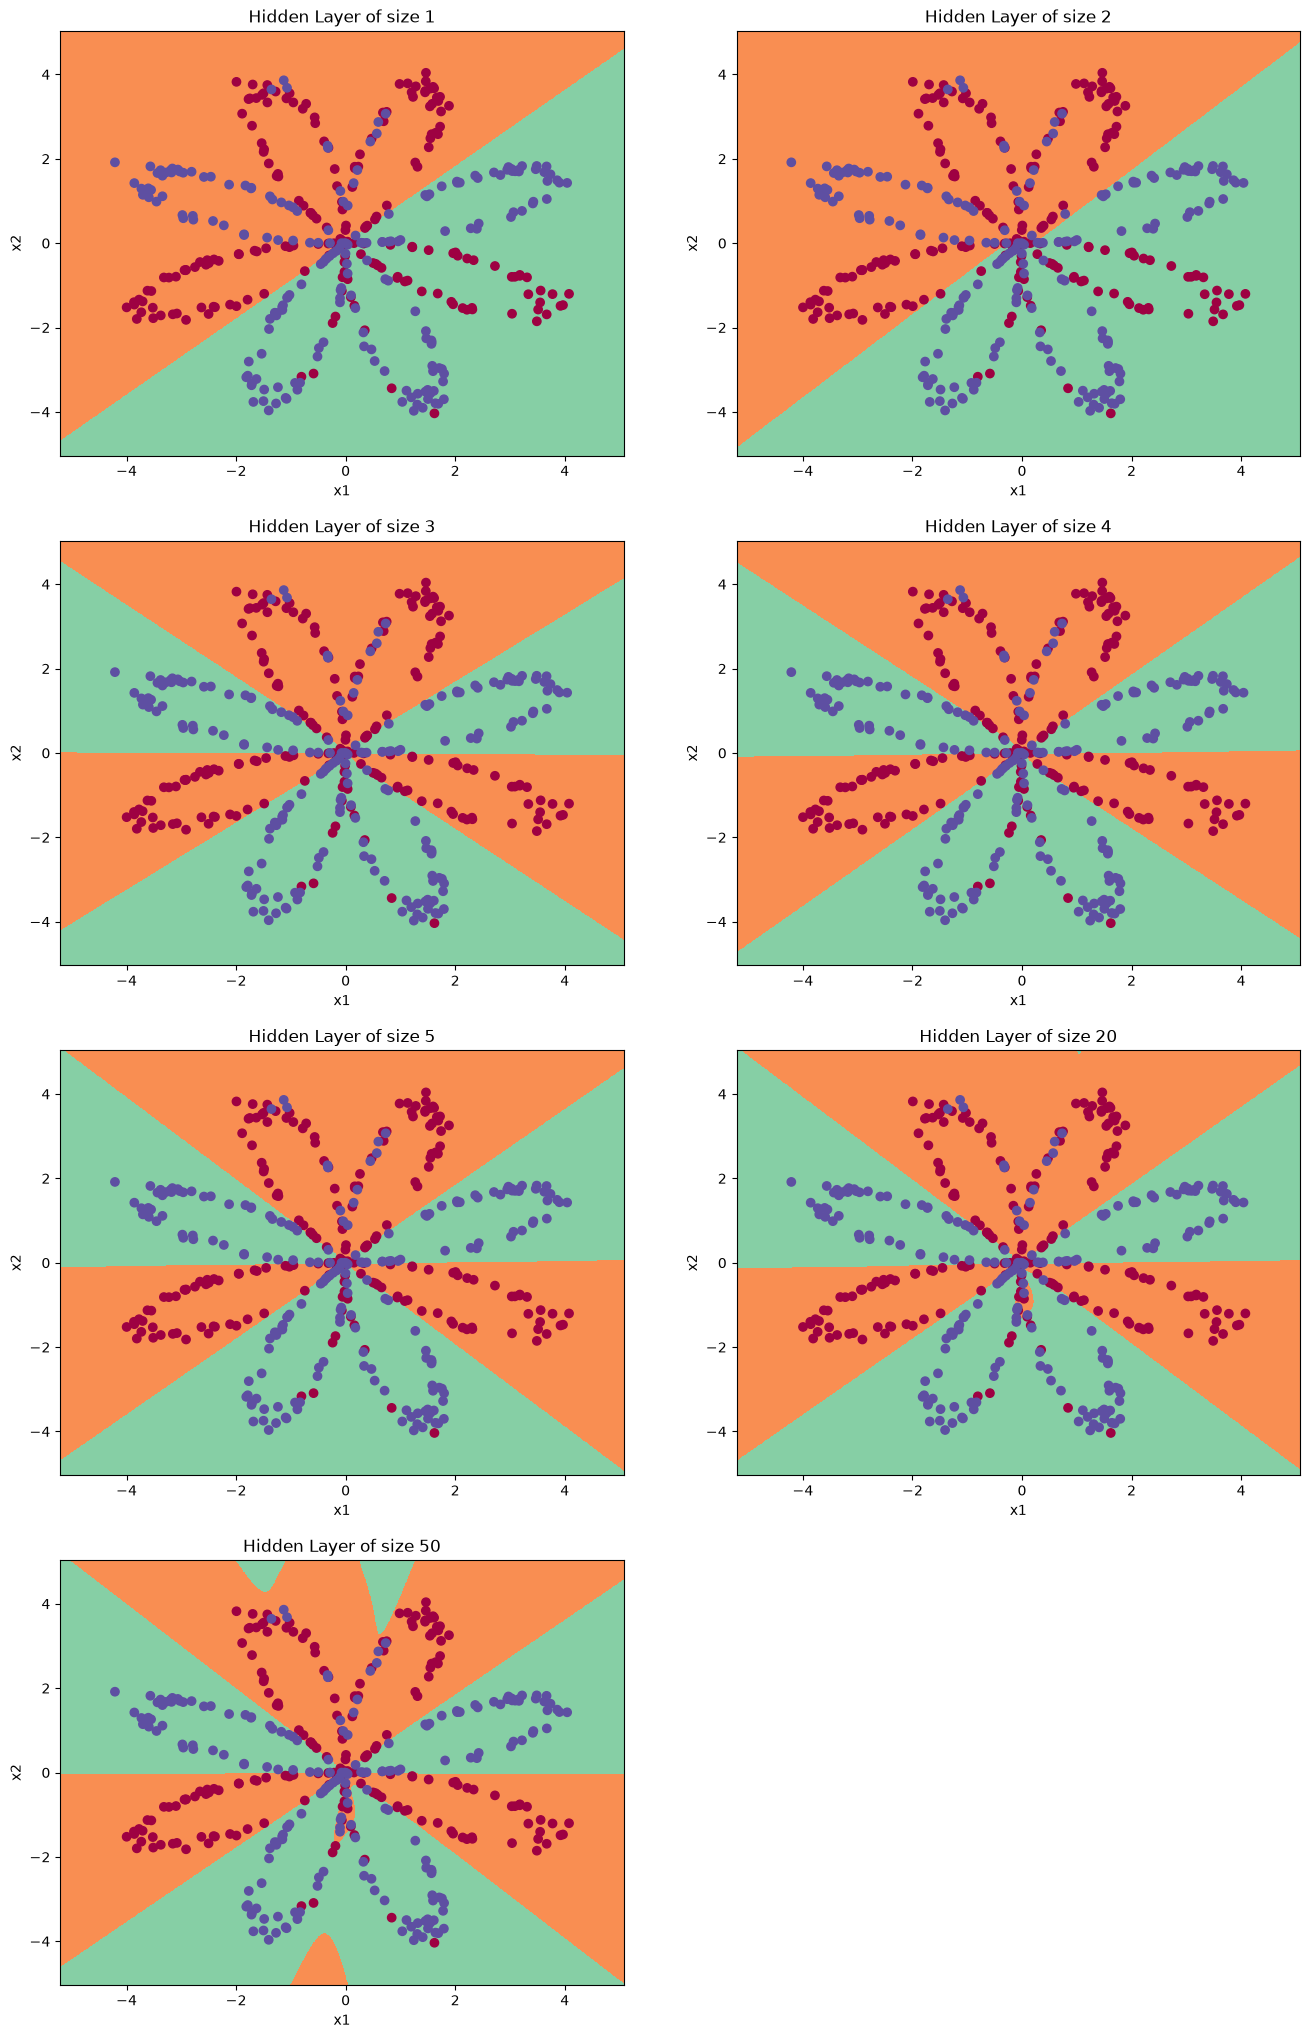

In [33]:
plt.figure(figsize=(16, 32))
hidden_layer_sizes = [1, 2, 3, 4, 5, 20, 50]
for i, n_h in enumerate(hidden_layer_sizes):
    plt.subplot(5, 2, i+1)
    plt.title('Hidden Layer of size %d' % n_h)
    parameters = nn_model(X, Y, n_h, num_iterations=5000)
    plot_decision_boundary(lambda x: predict(parameters, x.T), X, Y)
    predictions = predict(parameters, X)
    accuracy = np.mean(predictions == Y) * 100
    print("Accuracy for {} hidden units: {:.2f} %".format(n_h, accuracy))